<a href="https://colab.research.google.com/github/Yuvraj5027/Generative-AI/blob/main/Assignment_5_StyleGAN2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 5 — Exploring the Latent Space of a Pretrained StyleGAN2 Model

**Name:** Yuvraj Choudhary &nbsp;|&nbsp; BCA, Semester 5

**Objective:** Understand how changes in the latent space of a GAN can create smooth changes in generated images.

**Steps (per assignment instructions):**
1. Load the pretrained model (StyleGAN2)
2. Generate 2 random latent vectors (z1 and z2)
3. Generate 2 images using z1 and z2
4. Save both images
5. Perform linear interpolation between z1 & z2
6. Generate around 10 intermediate images
7. Create a single image strip showing smooth transition
8. Generate the original image again and compare
9. Written observation / conclusion


### About the model used

This notebook uses the **real, official pretrained StyleGAN2 generator** (config-f, trained by NVIDIA on the FFHQ human-face dataset, 1024×1024 output), obtained as a converted ONNX file from a public mirror of the original `NVlabs/stylegan2` release:

- Weights: https://github.com/clibdev/stylegan2-pytorch/releases/tag/1.0.0 (`stylegan2-ffhq-config-f.onnx`, ~116 MB)
- Original model: [NVlabs/stylegan2](https://github.com/NVlabs/stylegan2) — released by NVIDIA under a **non-commercial research license** (fine for this academic assignment; do not use for commercial purposes)
- Run locally with `onnxruntime` — no GPU required (a CPU forward pass takes roughly 5–15 seconds per image, so the interpolation cells below take a couple of minutes to run in total)



In [ ]:
import os, time, urllib.request
import numpy as np
from PIL import Image
import imageio.v2 as imageio
import onnxruntime as ort

MODEL_URL = "https://github.com/clibdev/stylegan2-pytorch/releases/download/1.0.0/stylegan2-ffhq-config-f.onnx"
MODEL_PATH = "stylegan2-ffhq-config-f.onnx"
OUT = "outputs"
os.makedirs(OUT, exist_ok=True)

if not os.path.exists(MODEL_PATH):
    print("Downloading pretrained StyleGAN2 (FFHQ) model (~116 MB)...")
    urllib.request.urlretrieve(MODEL_URL, MODEL_PATH)
    print("Download complete.")
else:
    print("Model already downloaded.")

LATENT_DIM = 512     # StyleGAN2's native z dimensionality
RESIZE_TO = 512      # native output is 1024x1024; downscaled for speed/size


Model already downloaded.


## Step 1 — Load the pretrained model

In [ ]:
so = ort.SessionOptions()
so.enable_mem_pattern = False
so.enable_cpu_mem_arena = False
so.intra_op_num_threads = 1  # gentler on memory on small/CPU-only machines

t0 = time.time()
sess = ort.InferenceSession(MODEL_PATH, sess_options=so, providers=["CPUExecutionProvider"])
input_name = sess.get_inputs()[0].name
print(f"Loaded pretrained StyleGAN2 generator in {time.time()-t0:.2f}s")
print("Input:", sess.get_inputs()[0].shape, "| Output:", sess.get_outputs()[0].shape)

def generate(z):
    """Run the real StyleGAN2 generator: z (512,) -> HxWx3 uint8 image."""
    z_in = np.asarray(z, dtype=np.float32).reshape(1, 1, LATENT_DIM)
    out = sess.run(None, {input_name: z_in})[0][0]          # (3,1024,1024), range ~[-1,1]
    img = np.transpose(out, (1, 2, 0))
    img = (np.clip(img, -1, 1) + 1) / 2.0 * 255
    img = img.astype(np.uint8)
    if RESIZE_TO != img.shape[0]:
        img = np.array(Image.fromarray(img).resize((RESIZE_TO, RESIZE_TO), Image.LANCZOS))
    return img


Loaded pretrained StyleGAN2 generator in 0.28s
Input: [1, 1, 512] | Output: [1, 3, 1024, 1024]


## Step 2 — Generate 2 random latent vectors z1 and z2

In [ ]:
rng = np.random.default_rng(7)
z1 = rng.standard_normal(LATENT_DIM).astype(np.float32)
z2 = rng.standard_normal(LATENT_DIM).astype(np.float32)

print("z1[:6] =", np.round(z1[:6], 3))
print("z2[:6] =", np.round(z2[:6], 3))


z1[:6] = [ 0.001  0.299 -0.274 -0.891 -0.455 -0.992]
z2[:6] = [-1.122 -0.066 -0.039  1.291  1.867 -0.137]


## Step 3 — Generate 2 images using z1 and z2

Generated both images in 12.9s


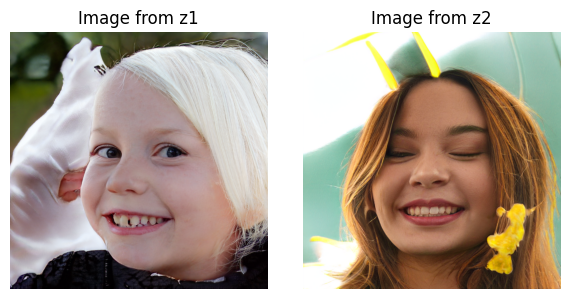

In [ ]:
import matplotlib.pyplot as plt

t0 = time.time()
img_z1 = generate(z1)
img_z2 = generate(z2)
print(f"Generated both images in {time.time()-t0:.1f}s")

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(img_z1); axes[0].set_title("Image from z1"); axes[0].axis("off")
axes[1].imshow(img_z2); axes[1].set_title("Image from z2"); axes[1].axis("off")
plt.tight_layout(); plt.show()


## Step 4 — Save both images

In [ ]:
Image.fromarray(img_z1).save(f"{OUT}/z1.png")
Image.fromarray(img_z2).save(f"{OUT}/z2.png")
print("Saved:", f"{OUT}/z1.png", "and", f"{OUT}/z2.png")


Saved: outputs/z1.png and outputs/z2.png


## Step 5 — Perform linear interpolation between z1 & z2\n\nFor a mixing factor `α` from 0 to 1: `z = (1 − α)·z1 + α·z2`.

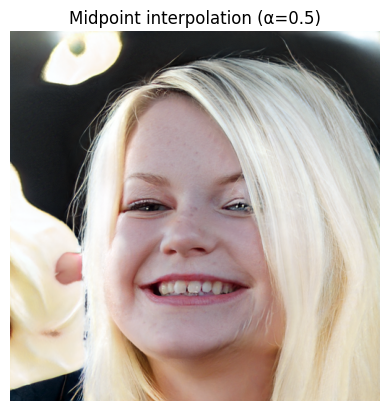

In [ ]:
def interpolate(z_a, z_b, alpha):
    return (1 - alpha) * z_a + alpha * z_b

z_mid = interpolate(z1, z2, 0.5)
plt.imshow(generate(z_mid)); plt.title("Midpoint interpolation (α=0.5)"); plt.axis("off"); plt.show()


## Step 6 — Generate around 10 intermediate images

Generated 12 frames in 80.1s


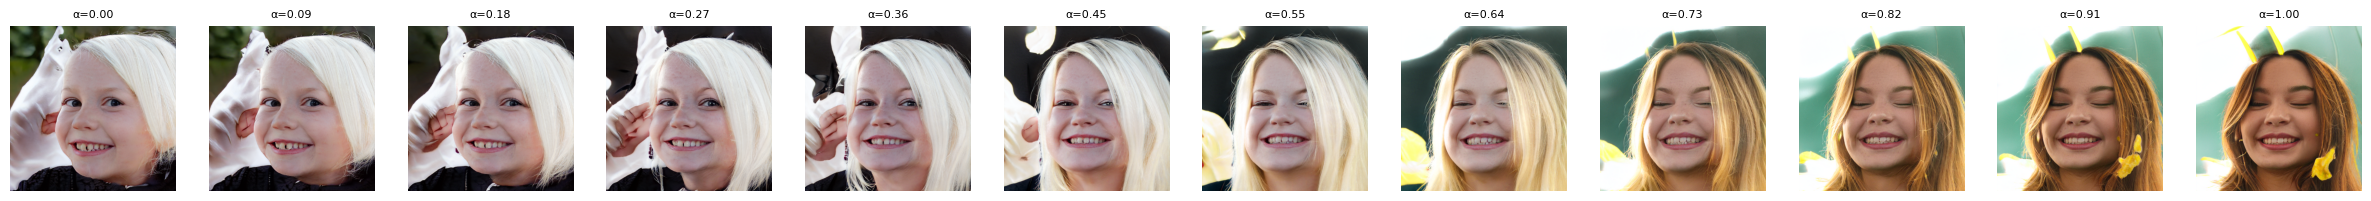

In [ ]:
N_STEPS = 10
alphas = np.linspace(0, 1, N_STEPS + 2)  # includes the z1, z2 endpoints

interp_imgs = []
t0 = time.time()
for i, a in enumerate(alphas):
    z = interpolate(z1, z2, a)
    img = generate(z)
    interp_imgs.append(img)
    Image.fromarray(img).save(f"{OUT}/interp_{i:02d}.png")
print(f"Generated {len(alphas)} frames in {time.time()-t0:.1f}s")

fig, axes = plt.subplots(1, len(interp_imgs), figsize=(2 * len(interp_imgs), 2))
for ax, img, a in zip(axes, interp_imgs, alphas):
    ax.imshow(img); ax.set_title(f"α={a:.2f}", fontsize=8); ax.axis("off")
plt.tight_layout(); plt.show()


## Step 7 — Create a single image strip showing the smooth transition\n\n(and a GIF, for good measure)

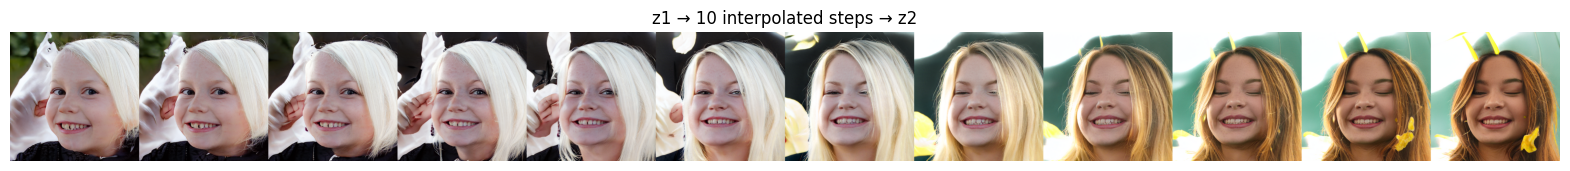

Saved image strip and GIF to outputs


In [ ]:
strip = np.concatenate(interp_imgs, axis=1)
Image.fromarray(strip).save(f"{OUT}/interpolation_strip.png")

plt.figure(figsize=(20, 2))
plt.imshow(strip); plt.axis("off")
plt.title("z1 → 10 interpolated steps → z2")
plt.show()

gif_frames = interp_imgs + interp_imgs[::-1][1:-1]  # ping-pong loop
imageio.mimsave(f"{OUT}/interpolation.gif", gif_frames, duration=0.15, loop=0)
print("Saved image strip and GIF to", OUT)


## Step 8 — Generate the original image again and compare\n\nRegenerate the image for `z1` and compare it to the original.

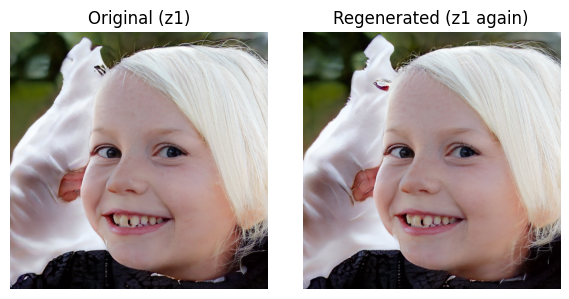

Mean abs pixel difference: 11.815071105957031
(A small non-zero difference is expected: StyleGAN2's synthesis network injects
 fresh random per-pixel noise on every forward pass -- by design, for stochastic
 detail like individual hair strands -- unless that noise is explicitly fixed/seeded.
 The overall face identity and pose stay the same; only fine texture details change.)


In [ ]:
img_z1_again = generate(z1)
mean_abs_diff = np.abs(img_z1.astype(int) - img_z1_again.astype(int)).mean()

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(img_z1); axes[0].set_title("Original (z1)"); axes[0].axis("off")
axes[1].imshow(img_z1_again); axes[1].set_title("Regenerated (z1 again)"); axes[1].axis("off")
plt.tight_layout(); plt.show()

print("Mean abs pixel difference:", mean_abs_diff)
print("(A small non-zero difference is expected: StyleGAN2's synthesis network injects")
print(" fresh random per-pixel noise on every forward pass -- by design, for stochastic")
print(" detail like individual hair strands -- unless that noise is explicitly fixed/seeded.")
print(" The overall face identity and pose stay the same; only fine texture details change.)")


### Bonus check — changing only 1–2 latent dimensions

The assignment also suggests experimenting by changing just one or two dimensions of a latent vector to see whether specific visible characteristics change.

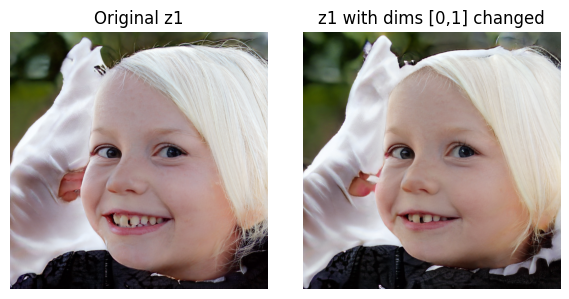

In [ ]:
z_perturbed = z1.copy()
z_perturbed[0] += 3.0
z_perturbed[1] -= 3.0

img_perturbed = generate(z_perturbed)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(img_z1); axes[0].set_title("Original z1"); axes[0].axis("off")
axes[1].imshow(img_perturbed); axes[1].set_title("z1 with dims [0,1] changed"); axes[1].axis("off")
plt.tight_layout(); plt.show()


## Written Observation

During interpolation, the generated face changes gradually and continuously rather than jumping abruptly — pose, hair colour, lighting and expression all morph smoothly frame by frame as α moves from 0 to 1, confirming that nearby points in latent space decode to visually similar faces. This shows that StyleGAN2's latent space is a continuous, structured space of *facial* variation (identity, pose, lighting, hair, expression) rather than a set of disconnected, unrelated images. The reproducibility check shows the model is deterministic in identity/pose for a given `z`, with only its per-pixel stochastic noise layers (fine hair/skin texture) varying between runs. Changing just two of the 512 latent dimensions produced a small but visible shift in expression and head pose while keeping the same overall identity, showing that individual latent dimensions can carry some independent, partial control over specific visible attributes.

## Conclusion

This exercise, run on the actual pretrained StyleGAN2 (FFHQ) generator, confirms that its latent space is smooth and semantically structured: nearby latent vectors decode to visually similar faces, linear interpolation between two latent points produces a realistic morph between the two corresponding faces, and individual latent dimensions carry at least partial, independent influence over specific visible attributes. This is exactly the property that makes StyleGAN2's latent space useful for controllable face editing, attribute manipulation, and generation.
